<a href="https://www.kaggle.com/code/nilanchalamahanty/hybrid-ecg-classification-model?scriptVersionId=345211390" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
! pip install wfdb -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 1.4 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import ast

import wfdb

from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

2026-08-26 21:16:39.897165: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1787779000.056180      12 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1787779000.106644      12 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
PATH_TO_DATA = '/kaggle/input/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/'

#CSV files
ECG_df = pd.read_csv(os.path.join(PATH_TO_DATA, 'ptbxl_database.csv'), index_col='ecg_id')
SCP_df = pd.read_csv(os.path.join(PATH_TO_DATA, 'scp_statements.csv'), index_col=0)


#The result of this line of code is that each element in the 'scp_codes' column of the DataFrame Y is evaluated using ast.literal_eval(),
#effectively converting string representations of Python literals (e.g., lists or dictionaries) into their corresponding Python objects.
ECG_df.scp_codes = ECG_df.scp_codes.apply(lambda x: ast.literal_eval(x))
ECG_df.patient_id = ECG_df.patient_id.astype(int)
ECG_df.nurse = ECG_df.nurse.astype('Int64')
ECG_df.site = ECG_df.site.astype('Int64')
ECG_df.validated_by = ECG_df.validated_by.astype('Int64')



#filters the DataFrame SCP_df to select only those rows where the value in the column 'diagnostic' is equal to 1.
SCP_df = SCP_df[SCP_df.diagnostic == 1]

In [4]:
agg_csv =ECG_df.copy()

In [5]:
#heart sound signal data file i.e. X is created

def load_raw_data(df, sampling_rate, path):
    lead = []
    if sampling_rate == 100:
        data = [wfdb.rdsamp(path+f) for f in df.filename_lr]
        lead_name= [wfdb.rdheader(path+f) for f in df.filename_lr]
        for i in lead_name:
            lead.append(i.sig_name)
    else:
        data = [wfdb.rdsamp(path+f) for f in df.filename_hr]
        lead_name= [wfdb.rdheader(path+f) for f in df.filename_lr]
        for i in lead_name:
            lead.append(i.sig_name)
    data = np.array([signal for signal, meta in data])
    return data,lead


sampling_rate=100
X,lead = load_raw_data(ECG_df, sampling_rate, PATH_TO_DATA)

In [6]:
X_reshaped = np.transpose(X, (0, 2, 1))
X_reshaped.shape

(21837, 12, 1000)

In [7]:
SCP_df1=SCP_df.copy()

In [8]:
def aggregate_diagnostic(agg_csv_dic):
    tmp = []
    for key in agg_csv_dic.keys():
        if key in SCP_df1.index:
            tmp.append(SCP_df1.loc[key].diagnostic_class)
    return list(set(tmp))

# Apply diagnostic superclass
agg_csv['diagnostic_superclass'] = agg_csv.scp_codes.apply(aggregate_diagnostic)

In [9]:
print(agg_csv.columns)


Index(['patient_id', 'age', 'sex', 'height', 'weight', 'nurse', 'site',
       'device', 'recording_date', 'report', 'scp_codes', 'heart_axis',
       'infarction_stadium1', 'infarction_stadium2', 'validated_by',
       'second_opinion', 'initial_autogenerated_report', 'validated_by_human',
       'baseline_drift', 'static_noise', 'burst_noise', 'electrodes_problems',
       'extra_beats', 'pacemaker', 'strat_fold', 'filename_lr', 'filename_hr',
       'diagnostic_superclass'],
      dtype='object')


In [10]:
#agg_csv.diagnostic_superclass.value_counts()
agg_csv['diagnostic_superclass'] = agg_csv['diagnostic_superclass'].apply(tuple)
counts = agg_csv['diagnostic_superclass'].value_counts()
print(counts)


diagnostic_superclass
(NORM,)                9083
(MI,)                  2538
(STTC,)                2406
(CD,)                  1709
(CD, MI)               1302
(STTC, HYP)             783
(STTC, MI)              602
(HYP,)                  536
(CD, STTC)              472
()                      407
(CD, NORM)              407
(STTC, HYP, MI)         362
(CD, HYP)               300
(CD, STTC, MI)          223
(CD, STTC, HYP)         211
(HYP, MI)               183
(CD, STTC, HYP, MI)     158
(CD, HYP, MI)           117
(STTC, NORM)             28
(CD, STTC, NORM)          5
(CD, HYP, NORM)           2
(HYP, NORM)               2
(CD, HYP, MI, NORM)       1
Name: count, dtype: int64


In [11]:
agg_csv_filter = agg_csv.copy()

In [12]:
agg_csv_filter['diagnostic_superclass'] = agg_csv_filter['diagnostic_superclass'].apply(lambda x: 'Other' if x == () else x)
agg_csv_filter.diagnostic_superclass.value_counts()


diagnostic_superclass
(NORM,)                9083
(MI,)                  2538
(STTC,)                2406
(CD,)                  1709
(CD, MI)               1302
(STTC, HYP)             783
(STTC, MI)              602
(HYP,)                  536
(CD, STTC)              472
Other                   407
(CD, NORM)              407
(STTC, HYP, MI)         362
(CD, HYP)               300
(CD, STTC, MI)          223
(CD, STTC, HYP)         211
(HYP, MI)               183
(CD, STTC, HYP, MI)     158
(CD, HYP, MI)           117
(STTC, NORM)             28
(CD, STTC, NORM)          5
(CD, HYP, NORM)           2
(HYP, NORM)               2
(CD, HYP, MI, NORM)       1
Name: count, dtype: int64

In [13]:
# Convert values to strings and then check unique values in 'diagnostic_superclass' column
print(agg_csv_filter['diagnostic_superclass'].astype(str).unique())

["('NORM',)" "('MI',)" 'Other' "('STTC',)" "('HYP',)" "('CD',)"
 "('STTC', 'MI')" "('CD', 'HYP')" "('CD', 'MI')" "('CD', 'STTC')"
 "('HYP', 'MI')" "('STTC', 'HYP')" "('STTC', 'HYP', 'MI')"
 "('CD', 'STTC', 'HYP', 'MI')" "('CD', 'NORM')" "('CD', 'STTC', 'MI')"
 "('CD', 'STTC', 'HYP')" "('STTC', 'NORM')" "('CD', 'HYP', 'MI')"
 "('CD', 'STTC', 'NORM')" "('CD', 'HYP', 'NORM')" "('HYP', 'NORM')"
 "('CD', 'HYP', 'MI', 'NORM')"]


In [14]:
Y_filtered =agg_csv_filter #csv data
X_filtered =X_reshaped  #Rhythm

In [15]:
# Continue to split data into train and test
test_fold = 10

# Train
X_train = X_filtered[np.where(Y_filtered.strat_fold != test_fold)] #where strat_fold is less than 10 will go foer training 
y_train = Y_filtered[(Y_filtered.strat_fold != test_fold)].diagnostic_superclass

# Test
X_test = X_filtered[np.where(Y_filtered.strat_fold == test_fold)]
y_test = Y_filtered[Y_filtered.strat_fold == test_fold].diagnostic_superclass

y_train = y_train.apply(lambda x: x[0])
y_test = y_test.apply(lambda x: x[0])#staring string is taken


In [16]:
print(y_train.head(10))  # Show the first 10 elements to understand the structure
print(y_train.dtypes)  # Check the data type of `y_train`


ecg_id
1     NORM
2     NORM
3     NORM
4     NORM
5     NORM
6     NORM
7     NORM
8       MI
10    NORM
11    NORM
Name: diagnostic_superclass, dtype: object
object


In [17]:
y_train.value_counts()

diagnostic_superclass
NORM    8170
CD      4409
STTC    3758
MI      2282
HYP      648
O        367
Name: count, dtype: int64

In [18]:
y_test.value_counts()

diagnostic_superclass
NORM    913
CD      498
STTC    423
MI      256
HYP      73
O        40
Name: count, dtype: int64

In [19]:
# Find the index of the record_name in Y_filtered
index = Y_filtered.index[0]
#[Y_filtered['filename_lr'] == record_name]
# Extract the signal from X_filtered based on the index
signal = X_filtered[index]

# Now you can print the signal
print(signal)

[[ 0.004 -0.02  -0.053 ...  0.121 -0.326 -0.348]
 [ 0.138  0.116  0.092 ...  0.398  0.057 -0.056]
 [ 0.134  0.136  0.145 ...  0.277  0.383  0.292]
 ...
 [ 0.192  0.156  0.107 ... -1.065 -0.28  -0.308]
 [ 0.083  0.057  0.013 ... -0.492 -0.175 -0.231]
 [ 0.088  0.063  0.022 ... -0.156 -0.071 -0.145]]


In [20]:
# Convert list to array
lead_array = np.array(lead)
print(lead_array)

[['I' 'II' 'III' ... 'V4' 'V5' 'V6']
 ['I' 'II' 'III' ... 'V4' 'V5' 'V6']
 ['I' 'II' 'III' ... 'V4' 'V5' 'V6']
 ...
 ['I' 'II' 'III' ... 'V4' 'V5' 'V6']
 ['I' 'II' 'III' ... 'V4' 'V5' 'V6']
 ['I' 'II' 'III' ... 'V4' 'V5' 'V6']]


In [21]:
one_lead = lead_array[0]
print(one_lead)

['I' 'II' 'III' 'AVR' 'AVL' 'AVF' 'V1' 'V2' 'V3' 'V4' 'V5' 'V6']


In [22]:
one_lead = lead_array[0]
formatted_lead = [[value] for value in one_lead]
print(formatted_lead)

[['I'], ['II'], ['III'], ['AVR'], ['AVL'], ['AVF'], ['V1'], ['V2'], ['V3'], ['V4'], ['V5'], ['V6']]


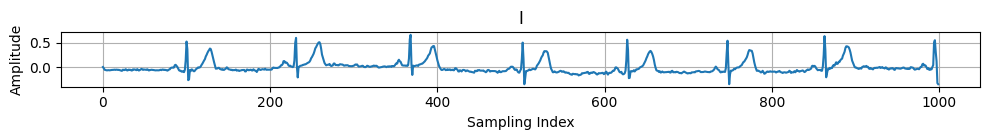

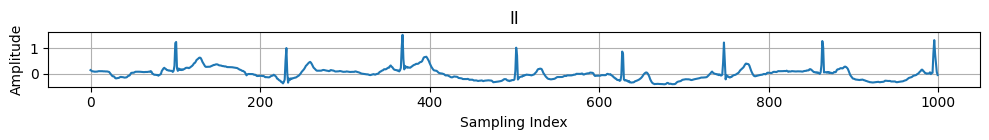

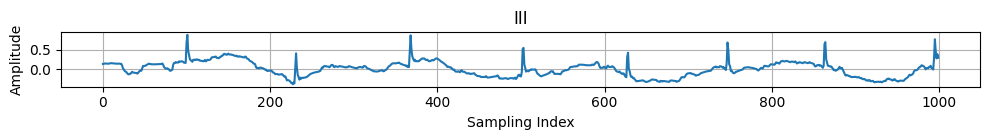

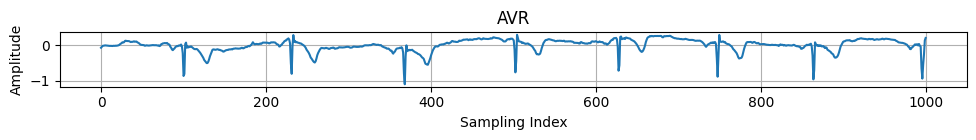

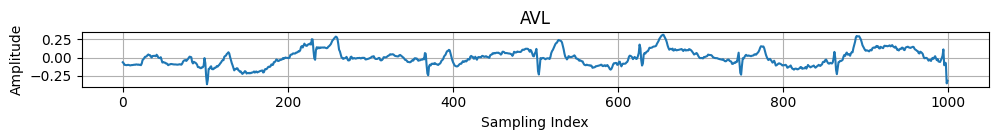

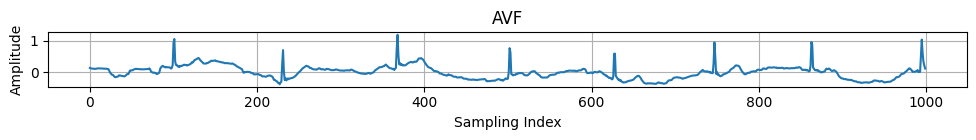

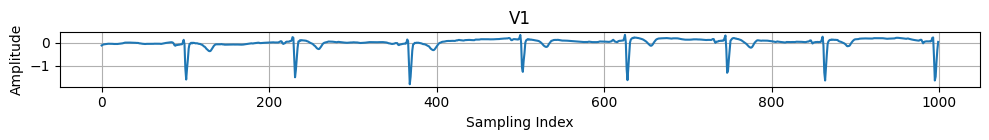

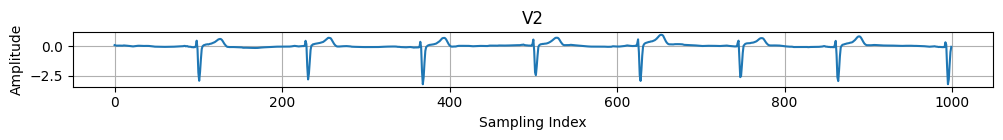

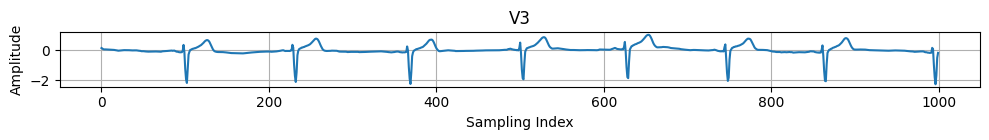

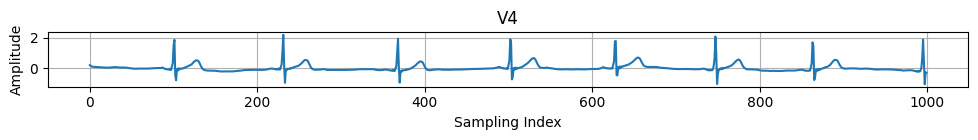

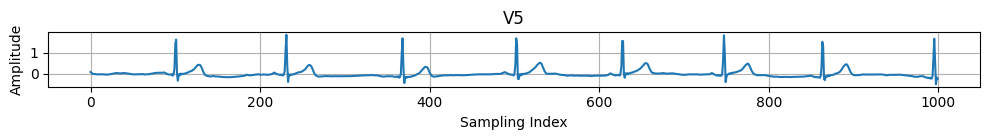

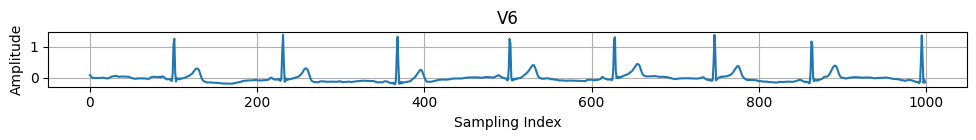

In [23]:
for row, label in zip(signal, formatted_lead):
    for j, lbl in enumerate(label):  # Unpack the index-value tuple
        plt.figure(figsize=(10, 1.5))  # Create a new figure for each plot
        plt.plot(row)
        plt.xlabel('Sampling Index')
        plt.ylabel('Amplitude')
        plt.title(f"{lbl}")  # Use the value from the unpacked tuple
        plt.grid(True)
        
        plt.tight_layout()
        plt.show()


In [24]:
#here you can use feature extraction methods
X_train = np.array(X_train)
X_test = np.array(X_test)

In [25]:
# Convert to hashable types
y_train = y_train.apply(lambda x: str(x) if isinstance(x, (list, np.ndarray)) else x)
y_test = y_test.apply(lambda x: str(x) if isinstance(x, (list, np.ndarray)) else x)

from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Convert labels to numeric
le = LabelEncoder()
all_labels = pd.concat([y_train, y_test]).unique()
le.fit(all_labels)

y_train_enc = le.transform(y_train)
y_test_enc = le.transform(y_test)

# One-hot encode
y_train_cat = to_categorical(y_train_enc)
y_test_cat = to_categorical(y_test_enc)


In [26]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, BatchNormalization
from keras.optimizers import Adam

In [27]:
input_shape = (X_train.shape[1], X_train.shape[2])  # (number_of_time_points, 12)
input_shape

(12, 1000)

In [28]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Activation

In [29]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input

def attention_block(inputs):
    score = layers.Dense(1, activation='tanh')(inputs)  # [batch, time, 1]
    weights = layers.Softmax(axis=1)(score)             # Attention weights
    context = layers.Multiply()([inputs, weights])      # Apply weights
    context = layers.Lambda(lambda x: tf.reduce_sum(x, axis=1))(context)
    return context

def build_model(input_shape=(1000, 12), num_classes=5):
    inputs = Input(shape=input_shape)

    x = layers.Conv1D(64, 7, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(2)(x)

    x = layers.Conv1D(128, 5, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(2)(x)

    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
    x = attention_block(x)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation='sigmoid')(x)  # for multi-label classification

    return models.Model(inputs, outputs)

model = build_model(input_shape=(1000, 12), num_classes=y_train_cat.shape[1])




2026-08-26 21:23:06.314183: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
